# 04 · Бейзлайн: ознаки тексту й фото + стекінг Ridge → LightGBM → пороги

**Ідея:** QWK — порядкова метрика, тому передбачаємо неперервне значення
і підбираємо пороги (`OptimizedRounder`) на OOF-передбаченнях.

**Ознаки:**
- ручні ознаки з `02_text_features` (regex, kNN-target по тексту) і `03_image_features`
  (zero-shot CLIP, якість фото, kNN-target по CLIP);
- TF-IDF (слова + символи) → SVD; CLIP-ембедінги фото → PCA;
- **стекінг 1-го рівня:** OOF-передбачення Ridge на «сирих» представленнях
  (CLIP фото, TF-IDF, CLIP тексту) як ознаки для LightGBM.

Target-залежні ознаки (kNN, Ridge) пораховані out-of-fold; строга nested-перевірка
(ознаки перераховуються без міток валідаційного фолду) дала ту саму оцінку — витоку немає.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.config import *
from src.utils import seed_everything, qwk, OptimizedRounder, write_submission
from src.features import tfidf_word_char
from src.models import run_lgb_cv, ridge_oof

seed_everything(SEED)
pd.set_option("display.max_colwidth", 200)
sns.set_theme(style="whitegrid")

In [2]:
from sklearn.decomposition import PCA, TruncatedSVD

train = pd.read_parquet(PROCESSED_DIR / "train_meta.parquet")
test = pd.read_parquet(PROCESSED_DIR / "test_meta.parquet")
y, folds, n_tr = train[TARGET_COL].values.astype(float), train["fold"].values, len(train)

def load_pair(name: str) -> pd.DataFrame:
    """Concatenate train+test parquet features (train rows first), aligned by PetID."""
    tr = pd.read_parquet(PROCESSED_DIR / f"{name}_train.parquet")
    te = pd.read_parquet(PROCESSED_DIR / f"{name}_test.parquet")
    assert (tr[ID_COL].values == train[ID_COL].values).all() and (te[ID_COL].values == test[ID_COL].values).all()
    return pd.concat([tr, te], ignore_index=True).drop(columns=ID_COL)

def load_emb(name: str) -> np.ndarray:
    return np.vstack([np.load(PROCESSED_DIR / f"{name}_train.npy"), np.load(PROCESSED_DIR / f"{name}_test.npy")])

text_feats, img_feats = load_pair("text_feats"), load_pair("img_feats")
n_photos = pd.concat([train[["n_photos"]], test[["n_photos"]]], ignore_index=True)
hand = pd.concat([n_photos, text_feats, img_feats], axis=1)

clip_img = np.hstack([load_emb("clip_pet_mean"), load_emb("clip_pet_first")])
clip_txt = load_emb("clip_text")
all_text = pd.concat([train[TEXT_COL], test[TEXT_COL]], ignore_index=True)
print("hand features:", hand.shape, " clip img:", clip_img.shape, " clip text:", clip_txt.shape)

hand features: (8322, 156)  clip img: (8322, 1536)  clip text: (8322, 768)


## 1. Зниження розмірності: TF-IDF → SVD, CLIP → PCA

SVD/PCA навчаються на train+test разом — це unsupervised, мітки не використовуються.

In [3]:
X_tfidf = tfidf_word_char(all_text)
svd = pd.DataFrame(TruncatedSVD(64, random_state=SEED).fit_transform(X_tfidf)).add_prefix("svd_")
pca = pd.DataFrame(PCA(32, random_state=SEED).fit_transform(load_emb("clip_pet_mean"))).add_prefix("clip_pca_")
X_tfidf.shape, svd.shape, pca.shape

((8322, 75602), (8322, 64), (8322, 32))

## 2. Стекінг 1-го рівня: Ridge на «сирих» представленнях

Кожна Ridge-модель — окремий «експерт» по своїй модальності. Їхні OOF-передбачення
зберігаємо (`oof_ridge_*.npy`) — вони знадобляться і для фінального стекінгу в 06.

In [4]:
ridge_inputs = {
    "ridge_clip_img": (clip_img, 3.3),
    "ridge_tfidf": (X_tfidf, 3.0),
    "ridge_clip_text": (clip_txt, 3.3),
}
ridge_cols, rows = {}, []
for name, (X, alpha) in ridge_inputs.items():
    oof, pred_te = ridge_oof(X[:n_tr], X[n_tr:], y, folds, alpha=alpha)
    np.save(PROCESSED_DIR / f"oof_{name}.npy", oof); np.save(PROCESSED_DIR / f"test_{name}.npy", pred_te)
    ridge_cols[name] = np.r_[oof, pred_te]
    rows.append({"model": name, "OOF QWK": qwk(y, OptimizedRounder().fit(oof, y).predict(oof))})
ridge = pd.DataFrame(ridge_cols)
pd.DataFrame(rows).round(4)

,model,OOF QWK
0,ridge_clip_img,0.5871
1,ridge_tfidf,0.3350
2,ridge_clip_text,0.2813


## 3. Абляція: який внесок кожної групи ознак

Одна й та сама LightGBM, змінюємо тільки набір ознак.

In [5]:
text_only = [n_photos, text_feats]
feature_sets = {
    "текст: ручні ознаки": text_only,
    "текст: + SVD + Ridge(TF-IDF)": text_only + [svd, ridge[["ridge_tfidf"]]],
    "фото: ручні ознаки": [n_photos, img_feats],
    "текст + фото: ручні": [hand],
    "+ SVD + PCA": [hand, svd, pca],
    "+ SVD + PCA + Ridge (усі)": [hand, svd, pca, ridge],
}
ablation = []
for name, parts in feature_sets.items():
    X = pd.concat(parts, axis=1)
    res = run_lgb_cv(X[:n_tr], X[n_tr:], y, folds, verbose=False)
    ablation.append({"набір ознак": name, "n_features": X.shape[1], "OOF QWK": res["qwk"]})
pd.DataFrame(ablation).round(4)

,набір ознак,n_features,OOF QWK
0,текст: ручні ознаки,41,0.3189
1,текст: + SVD + Ridge(TF-IDF),106,0.3398
2,фото: ручні ознаки,116,0.5581
3,текст + фото: ручні,156,0.5760
4,+ SVD + PCA,252,0.5775
5,+ SVD + PCA + Ridge (усі),255,0.6107


## 4. Фінальна модель бейзлайну: усереднення по 3 сідах

QWK на ~6.4k об'єктах шумна (±0.01 між запусками), тому усереднюємо кілька сідів LightGBM.

In [6]:
X = pd.concat([hand, svd, pca, ridge], axis=1)
X_tr, X_te = X[:n_tr], X[n_tr:]
params = dict(learning_rate=0.01, num_leaves=15, min_data_in_leaf=40)

oof, pred_te, imp = np.zeros(n_tr), np.zeros(len(X_te)), 0
seeds = [SEED, SEED + 1, SEED + 2]
for s in seeds:
    res = run_lgb_cv(X_tr, X_te, y, folds, params={**params, "seed": s}, verbose=False)
    print(f"seed {s}: OOF QWK {res['qwk']:.4f}")
    oof += res["oof"] / len(seeds); pred_te += res["test"] / len(seeds); imp = imp + res["importance"] / len(seeds)

rounder = OptimizedRounder().fit(oof, y)
print(f"\nseed-averaged OOF QWK: {qwk(y, rounder.predict(oof)):.4f}   thresholds: {rounder.coef_.round(3)}")
print("naive rounding:", round(qwk(y, np.clip(np.round(oof), 1, 4)), 4))
np.save(PROCESSED_DIR / "oof_baseline.npy", oof); np.save(PROCESSED_DIR / "test_baseline.npy", pred_te)

seed 42: OOF QWK 0.6118


seed 43: OOF QWK 0.6111


seed 44: OOF QWK 0.6089



seed-averaged OOF QWK: 0.6125   thresholds: [1.901 2.531 3.266]
naive rounding: 0.5323


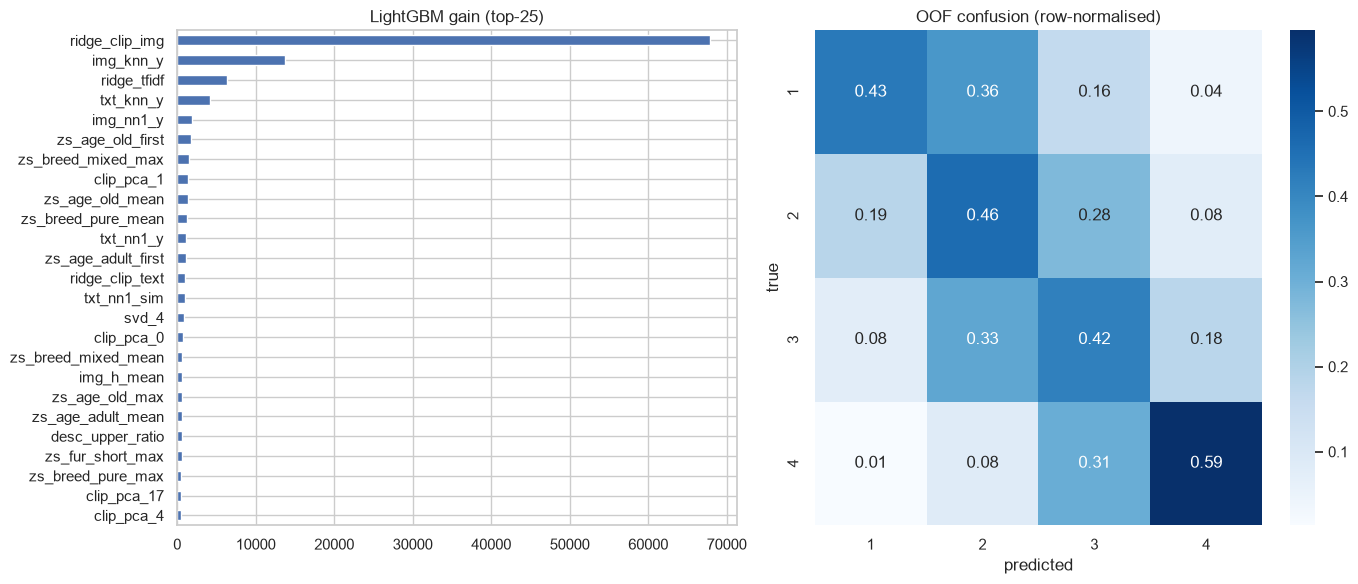

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
imp.sort_values(ascending=False).head(25).plot.barh(ax=axes[0], title="LightGBM gain (top-25)").invert_yaxis()
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y, rounder.predict(oof), labels=[1, 2, 3, 4], normalize="true")
sns.heatmap(cm, annot=True, fmt=".2f", cmap="Blues", xticklabels=[1, 2, 3, 4], yticklabels=[1, 2, 3, 4], ax=axes[1])
axes[1].set(xlabel="predicted", ylabel="true", title="OOF confusion (row-normalised)")
plt.tight_layout();

## 5. Сабмішн

Пороги — з OOF. Перевіряємо, що розподіл класів на test схожий на OOF (грубий sanity-check
на зсув між train і test).

In [8]:
pred_cls = rounder.predict(pred_te)
dist = pd.DataFrame({
    "train (true)": pd.Series(y).value_counts(normalize=True),
    "OOF (pred)": pd.Series(rounder.predict(oof)).value_counts(normalize=True),
    "test (pred)": pd.Series(pred_cls).value_counts(normalize=True),
}).sort_index().round(3)
display(dist)
write_submission(test[ID_COL], pred_cls, "04_baseline_lgb_stack");

,train (true),OOF (pred),test (pred)
1.0,0.186,0.152,0.168
2.0,0.276,0.290,0.260
3.0,0.206,0.295,0.265
4.0,0.332,0.264,0.307


Saved C:\Users\pbori\Documents\Courses\Neoversity\DeepL\neoversity-dl-cv-final\submissions\04_baseline_lgb_stack.csv  shape=(1891, 2)
{1: 318, 2: 491, 3: 502, 4: 580}


## Висновки

- **Абляція:** ручні ознаки тексту 0.319 → + SVD/Ridge(TF-IDF) 0.340; фото 0.558; текст + фото 0.576;
  + SVD/PCA 0.578; **+ OOF Ridge-моделей як ознаки 0.611**; 3 сіди — **0.6125**.
- **Найбільший приріст дав стекінг** (+0.033): Ridge на «сирих» 1 536-вимірних CLIP-ембедінгах сам дає 0.587
  і стискає їх в одну сильну ознаку, з якою LightGBM працює краще, ніж з PCA-компонентами.
  SVD/PCA майже нічого не додали.
- **Строга nested-перевірка стекінгу** (Ridge-ознаки перераховуються без міток валідаційного фолду): 0.612 —
  витоку немає.
- **Підбір порогів критичний:** 0.61 з `OptimizedRounder` проти 0.53 при простому округленні.
- **Лідерборд:** public **0.7912**. Розрив з OOF великий, але частка «двійників» у test така сама, як у
  валідаційних фолдах, тож найімовірніше це дисперсія малої public-частини. Орієнтуємося на OOF.
- Урок: Kaggle відхилив перший сабмішн — ID треба віддавати точно як у test.csv (4 ID без ведучого нуля).